In [2]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Google drive mount (it is only needed once, but it is better to include it)
drive.mount('/content/drive')
print("Google Drive connected sucessfully. Everything is ready for a Patient-level split.")

Mounted at /content/drive
Google Drive connected sucessfully. Everything is ready for a Patient-level split.


New patient-level split splitting the info in 4 groups
1. Preprocessing

In [3]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification" "/content/dataset_original_local"

In [5]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Dictionary mapping the original classes to the 4 biological families
CLASS_MAPPING = {
    'ductal_carcinoma': 'Ductal_Family',
    'papillary_carcinoma': 'Ductal_Family',
    'mucinous_carcinoma': 'Ductal_Family',
    'fibroadenoma': 'Fibroepithelial_Family',
    'phyllodes_tumor': 'Fibroepithelial_Family',
    'adenosis': 'Adenomas_and_Glandular',
    'tubular_adenoma': 'Adenomas_and_Glandular',
    'lobular_carcinoma': 'Lobular_Carcinoma'
}

def get_patient_id(filename):
    """
    Extracts a unique patient ID from the filename.
    """
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_families_split(origin_path, final_path='/content/data_split_families', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]
        patients_dict = {c: {} for c in classes}

        # Group images by patient ID for each original class
        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        amp_train_count, amp_test_count = 0, 0

        for c in classes:
            all_patients = list(patients_dict[c].keys())

            if len(all_patients) == 1:
                train_p = all_patients
                test_p = []
            else:
                train_p, test_p = train_test_split(all_patients, train_size=train_size, random_state=seed)

            # CORE LOGIC: Map the original class to its superclass (Family)
            super_class = CLASS_MAPPING.get(c, c)
            train_dest = final_p / 'train' / super_class
            test_dest = final_p / 'test' / super_class
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")
                    amp_train_count += 1

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")
                    amp_test_count += 1

        print(f" Zoom {amp} processed (4 Families Split):")
        print(f"   - Images added to TRAIN: {amp_train_count}")
        print(f"   - Images added to TEST : {amp_test_count}\n")

        total_train += amp_train_count
        total_test += amp_test_count

    print("-" * 50)
    print("The 4-families patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total images in TRAIN: {total_train}")
    print(f"Total images in TEST: {total_test}")

# Using your local dataset directory
source_path = '/content/dataset_original_local'
local_dest_path = '/content/data_split_families'

process_dataset_families_split(origin_path=source_path, final_path=local_dest_path)

Detected zooms: ['200X', '40X', '400X', '100X']

 Zoom 200X processed (4 Families Split):
   - Images added to TRAIN: 1579
   - Images added to TEST : 434

 Zoom 40X processed (4 Families Split):
   - Images added to TRAIN: 1505
   - Images added to TEST : 490

 Zoom 400X processed (4 Families Split):
   - Images added to TRAIN: 1319
   - Images added to TEST : 501

 Zoom 100X processed (4 Families Split):
   - Images added to TRAIN: 1485
   - Images added to TEST : 596

--------------------------------------------------
The 4-families patient-level split has finished successfully.
New clean data stored in: '/content/data_split_families/'
Total images in TRAIN: 5888
Total images in TEST: 2021


2. Dataloaders and Class Balancing via Data Augmentation

In [6]:
import torch
import numpy as np
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# Data Augmentation transforms for the training set
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test dataset ALWAYS remains without augmentations
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_da = datasets.ImageFolder(root='/content/data_split_families/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split_families/test', transform=transform_test)

# --- CONFIGURATION TO EQUALIZE CLASSES TO THE MAJORITY CLASS ---
# Count the number of images per class in the training set
class_counts = np.bincount(train_dataset_da.targets)
max_class_count = max(class_counts) # Find the class with the most images

# Calculate the weight for each class (inversely proportional to its frequency)
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset_da.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# FIX: Convert the result to a native Python 'int' so PyTorch accepts it
balanced_num_samples = int(max_class_count * len(train_dataset_da.classes))

# Create the sampler with replacement to balance the batches
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

# DataLoaders (keeping batch_size=32)
# IMPORTANT: shuffle MUST be False when using a sampler
train_loader_da = DataLoader(train_dataset_da, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total original Train images: {len(train_dataset_da)}")
print(f"Effective Train images per epoch (after DA balancing): {balanced_num_samples}")
print(f"Detected 4 Families: {train_dataset_da.class_to_idx}")

Total original Train images: 5888
Effective Train images per epoch (after DA balancing): 14796
Detected 4 Families: {'Adenomas_and_Glandular': 0, 'Ductal_Family': 1, 'Fibroepithelial_Family': 2, 'Lobular_Carcinoma': 3}


3. CNN model initialization

In [7]:
import torch.nn as nn
import torch.optim as optim

# Device configuration (CUDA for cloud, MPS for Apple Silicon, fallback to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained ResNet18
model_cnn_da = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Ensure all layers are unfrozen (for full fine-tuning)
for param in model_cnn_da.parameters():
    param.requires_grad = True

# Modify the final layer for the new 4-class classification
num_ftrs = model_cnn_da.fc.in_features
num_classes = len(train_dataset_da.classes) # Automatically detects 4 classes

# Replace the last layer
model_cnn_da.fc = nn.Linear(num_ftrs, num_classes)
model_cnn_da = model_cnn_da.to(device)

# Standard loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn_da.parameters(), lr=0.0001)

print(f"ResNet18 architecture ready for {num_classes}-families classification.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.6MB/s]


ResNet18 architecture ready for 4-families classification.


4. Training and saving phase

In [8]:
import time
from sklearn.metrics import classification_report

NUM_EPOCHS = 15
print("Starting training for the 4-Families Data Augmentation experiment...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_cnn_da.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_cnn_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_cnn_da.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_cnn_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Family...")
# Dynamically extract the class names from the dataset
class_names = [train_dataset_da.classes[i] for i in range(num_classes)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model with a name indicating it is the 4 families split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/cnn_ResNet18_DA_4families.pth"
torch.save(model_cnn_da.state_dict(), save_path)
print(f"Model saved as 'cnn_ResNet18_DA_4families.pth'")

Starting training for the 4-Families Data Augmentation experiment...

Epoch 1/15 (121.3s) -> Train Loss: 0.3835 | Train Acc: 0.8544 || Test Loss: 1.1910 | Test Acc: 0.7432
Epoch 2/15 (117.4s) -> Train Loss: 0.1867 | Train Acc: 0.9345 || Test Loss: 1.0284 | Test Acc: 0.7665
Epoch 3/15 (116.9s) -> Train Loss: 0.1327 | Train Acc: 0.9536 || Test Loss: 1.2851 | Test Acc: 0.7798
Epoch 4/15 (117.4s) -> Train Loss: 0.1053 | Train Acc: 0.9640 || Test Loss: 1.4319 | Test Acc: 0.7714
Epoch 5/15 (117.5s) -> Train Loss: 0.0983 | Train Acc: 0.9681 || Test Loss: 1.1345 | Test Acc: 0.7912
Epoch 6/15 (116.9s) -> Train Loss: 0.0749 | Train Acc: 0.9754 || Test Loss: 1.2089 | Test Acc: 0.7843
Epoch 7/15 (117.5s) -> Train Loss: 0.0742 | Train Acc: 0.9751 || Test Loss: 1.6880 | Test Acc: 0.7714
Epoch 8/15 (120.2s) -> Train Loss: 0.0742 | Train Acc: 0.9757 || Test Loss: 1.8532 | Test Acc: 0.7635
Epoch 9/15 (117.7s) -> Train Loss: 0.0715 | Train Acc: 0.9763 || Test Loss: 1.4110 | Test Acc: 0.7838
Epoch 10/15 

5. Graphical representation of the data and calculated metrics

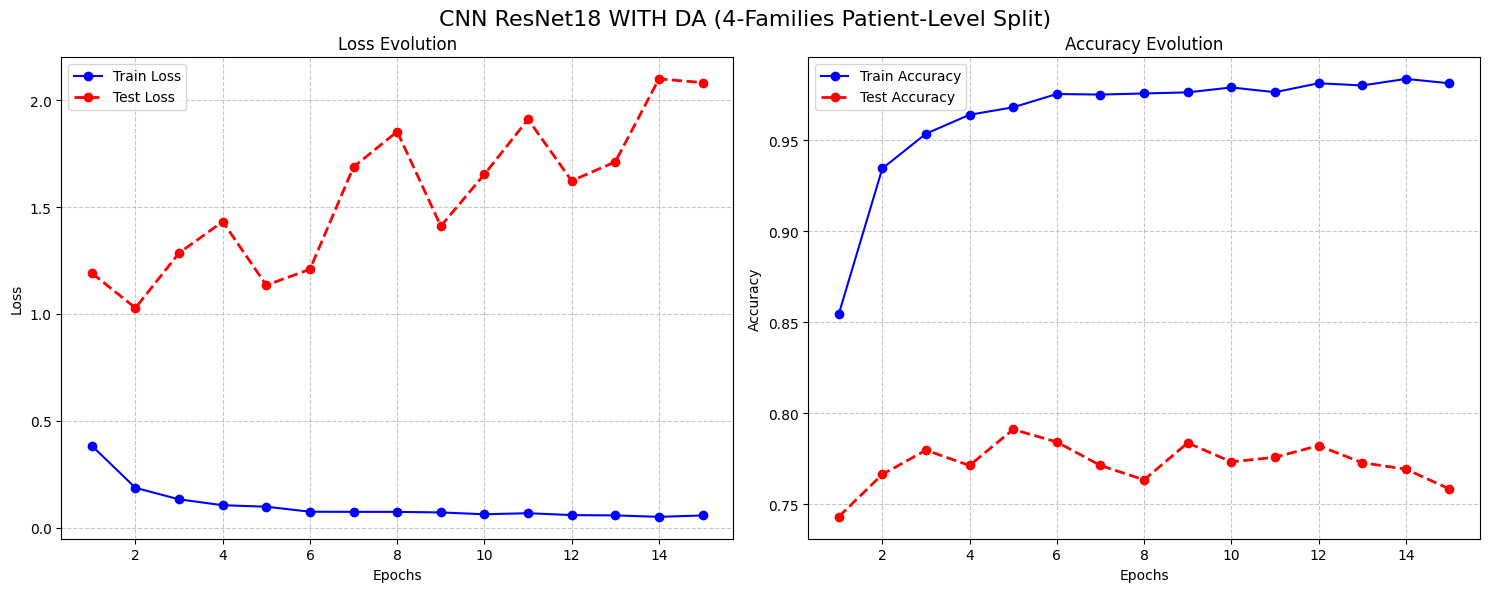

In [9]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (CNN ResNet18 WITH Data Augmentation - 4 Families)
epochs = list(range(1, 16))

train_loss = [0.3835, 0.1867, 0.1327, 0.1053, 0.0983, 0.0749, 0.0742, 0.0742, 0.0715, 0.0630, 0.0679, 0.0591, 0.0576, 0.0510, 0.0574]
test_loss = [1.1910, 1.0284, 1.2851, 1.4319, 1.1345, 1.2089, 1.6880, 1.8532, 1.4110, 1.6536, 1.9103, 1.6227, 1.7118, 2.0997, 2.0824]

train_acc = [0.8544, 0.9345, 0.9536, 0.9640, 0.9681, 0.9754, 0.9751, 0.9757, 0.9763, 0.9790, 0.9764, 0.9813, 0.9801, 0.9837, 0.9813]
test_acc = [0.7432, 0.7665, 0.7798, 0.7714, 0.7912, 0.7843, 0.7714, 0.7635, 0.7838, 0.7734, 0.7759, 0.7823, 0.7729, 0.7694, 0.7585]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('CNN ResNet18 WITH DA (4-Families Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('cnn_resnet18_4families_with_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

6. Confusion matrix of the model

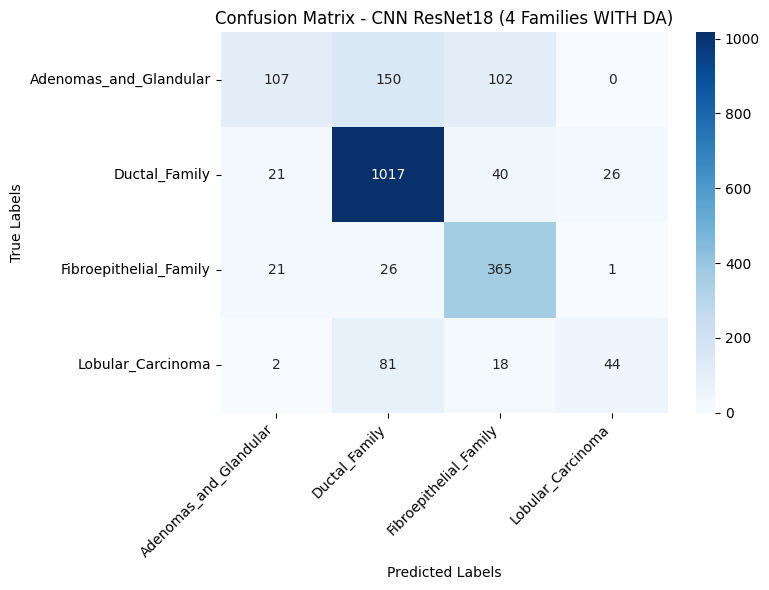

In [10]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the CNN model is in evaluation mode
model_cnn_da.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (e.g., GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_cnn_da(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU for scikit-learn compatibility
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Dynamically fetch the 4 family names from the dataset (ensure order matches PyTorch's internal mapping)
class_names = train_dataset_da.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - CNN ResNet18 (4 Families WITH DA)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig('cnn_resnet18_4families_confusion_matrix.png', dpi=300) # Uncomment to save
plt.show()

Let's now move on to the ViT with the same characteristics as used previously in the CNN
1. ViT model initialisation

In [11]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Device configuration (CUDA for cloud, MPS for Apple Silicon, fallback to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained Vision Transformer (ViT Base 16)
model_vit_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Ensure all layers are unfrozen (for full fine-tuning)
for param in model_vit_da.parameters():
    param.requires_grad = True

# Modify the final classification head for the 4-families classification
# In torchvision's ViT, the classification layer is stored in 'heads.head'
num_ftrs = model_vit_da.heads.head.in_features
num_classes = len(train_dataset_da.classes) # Automatically detects 4 classes

# Replace the last layer
model_vit_da.heads.head = nn.Linear(num_ftrs, num_classes)
model_vit_da = model_vit_da.to(device)

# Standard loss function and optimizer
criterion = nn.CrossEntropyLoss()
# ViTs sometimes benefit from a slightly lower learning rate, but 1e-4 is a safe starting point
optimizer = optim.Adam(model_vit_da.parameters(), lr=0.0001)

print(f"ViT architecture ready for {num_classes}-families classification.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 126MB/s]


ViT architecture ready for 4-families classification.


2. Train, save and metrics of the model

In [12]:
import time
from sklearn.metrics import classification_report

NUM_EPOCHS = 15
print("Starting training for the 4-Families Data Augmentation experiment (ViT)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # ==========================================
    # TRAINING PHASE
    # ==========================================
    model_vit_da.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for inputs, labels in train_loader_da:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model_vit_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # ==========================================
    # VALIDATION (TEST) PHASE
    # ==========================================
    model_vit_da.eval()
    running_test_loss = 0.0
    running_test_corrects = 0
    total_test = 0

    # Lists to store true labels and predictions for the final clinical report
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model_vit_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Extract predictions only during the final epoch to generate the matrix metrics
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nTraining finished successfully.")

# ==========================================
# FINAL CLINICAL METRICS REPORT
# ==========================================
print("\nGenerating Detailed Performance Report per Family...")
# Dynamically extract the class names from the dataset
class_names = [train_dataset_da.classes[i] for i in range(num_classes)]

# Generate the report balancing precision, recall, and F1-score
report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Save the model with a name indicating it is the ViT 4-families split
save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_DA_4families.pth"
torch.save(model_vit_da.state_dict(), save_path)
print(f"Model saved as 'vit_DA_4families.pth'")

Starting training for the 4-Families Data Augmentation experiment (ViT)...

Epoch 1/15 (669.5s) -> Train Loss: 0.3812 | Train Acc: 0.8522 || Test Loss: 0.9798 | Test Acc: 0.7650
Epoch 2/15 (670.2s) -> Train Loss: 0.1558 | Train Acc: 0.9457 || Test Loss: 1.0686 | Test Acc: 0.7912
Epoch 3/15 (669.6s) -> Train Loss: 0.1140 | Train Acc: 0.9619 || Test Loss: 1.0289 | Test Acc: 0.7808
Epoch 4/15 (667.9s) -> Train Loss: 0.0905 | Train Acc: 0.9704 || Test Loss: 0.8471 | Test Acc: 0.8070
Epoch 5/15 (668.5s) -> Train Loss: 0.0858 | Train Acc: 0.9715 || Test Loss: 1.1711 | Test Acc: 0.7778
Epoch 6/15 (667.5s) -> Train Loss: 0.0748 | Train Acc: 0.9748 || Test Loss: 1.0318 | Test Acc: 0.8060
Epoch 7/15 (668.1s) -> Train Loss: 0.0722 | Train Acc: 0.9768 || Test Loss: 1.0685 | Test Acc: 0.7556
Epoch 8/15 (669.8s) -> Train Loss: 0.0716 | Train Acc: 0.9767 || Test Loss: 1.1346 | Test Acc: 0.7867
Epoch 9/15 (669.7s) -> Train Loss: 0.0664 | Train Acc: 0.9788 || Test Loss: 1.1007 | Test Acc: 0.8080
Epoch 

4. Graphical representation of the data

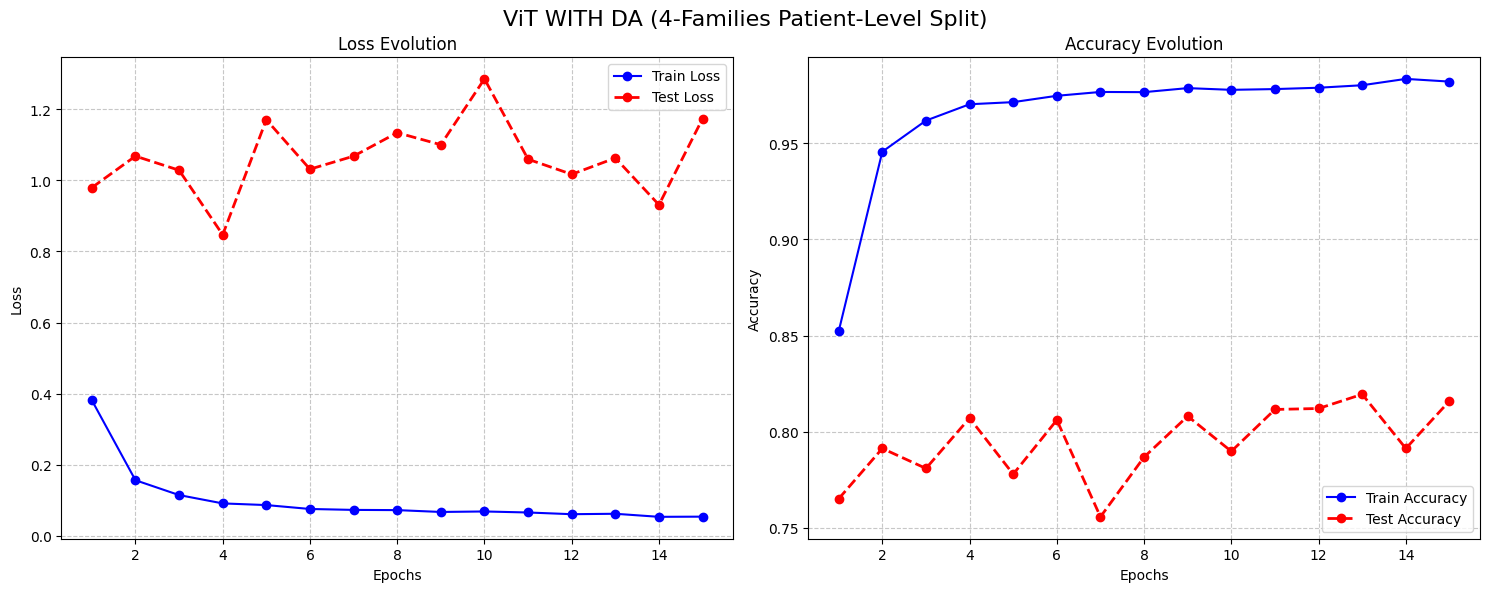

In [14]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ViT WITH Data Augmentation - 4 Families)
epochs = list(range(1, 16))

train_loss = [0.3812, 0.1558, 0.1140, 0.0905, 0.0858, 0.0748, 0.0722, 0.0716, 0.0664, 0.0678, 0.0649, 0.0601, 0.0613, 0.0527, 0.0532]
test_loss  = [0.9798, 1.0686, 1.0289, 0.8471, 1.1711, 1.0318, 1.0685, 1.1346, 1.1007, 1.2861, 1.0598, 1.0174, 1.0633, 0.9314, 1.1743]

train_acc  = [0.8522, 0.9457, 0.9619, 0.9704, 0.9715, 0.9748, 0.9768, 0.9767, 0.9788, 0.9779, 0.9783, 0.9790, 0.9803, 0.9836, 0.9822]
test_acc   = [0.7650, 0.7912, 0.7808, 0.8070, 0.7778, 0.8060, 0.7556, 0.7867, 0.8080, 0.7897, 0.8115, 0.8120, 0.8194, 0.7912, 0.8159]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT WITH DA (4-Families Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_4families_with_da_metrics.png', dpi=300) # Uncomment to save
plt.show()

5. Confusion Matrix


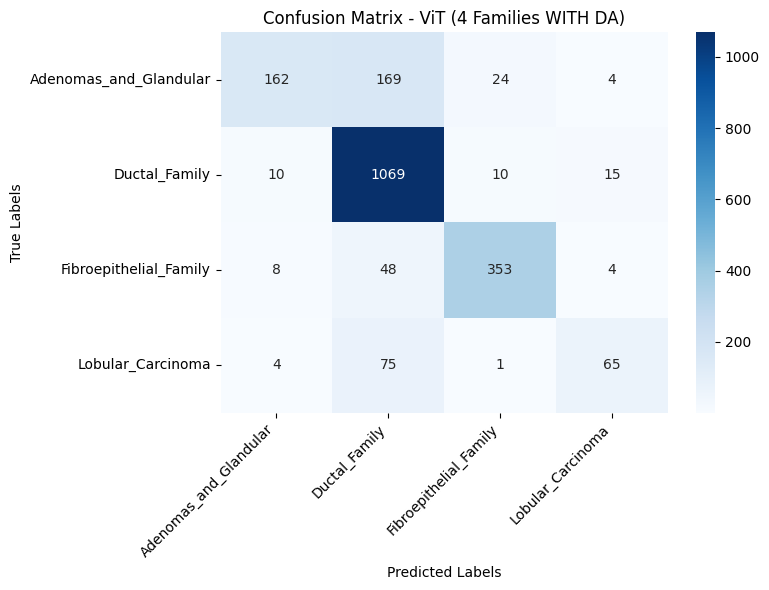

In [15]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure the ViT model is in evaluation mode
model_vit_da.eval()

all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move tensors to the configured device (e.g., GPU T4)
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model_vit_da(inputs)
        _, preds = torch.max(outputs, 1)

        # Move predictions and true labels back to CPU for scikit-learn compatibility
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Dynamically fetch the 4 family names from the dataset (ensure order matches PyTorch's mapping)
class_names = train_dataset_da.classes

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT (4 Families WITH DA)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig('vit_4families_confusion_matrix.png', dpi=300) # Uncomment to save
plt.show()

Next try...

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 179MB/s]


Starting training for the 4-Families with Focal Loss (ViT)...

Epoch 1/15 (695.2s) -> Train Loss: 0.2207 | Train Acc: 0.7925 || Test Loss: 0.3104 | Test Acc: 0.7455
Epoch 2/15 (707.7s) -> Train Loss: 0.0627 | Train Acc: 0.9324 || Test Loss: 0.3350 | Test Acc: 0.7782
Epoch 3/15 (708.4s) -> Train Loss: 0.0374 | Train Acc: 0.9606 || Test Loss: 0.3439 | Test Acc: 0.7513
Epoch 4/15 (707.1s) -> Train Loss: 0.0392 | Train Acc: 0.9602 || Test Loss: 0.3611 | Test Acc: 0.7487
Epoch 5/15 (709.6s) -> Train Loss: 0.0296 | Train Acc: 0.9658 || Test Loss: 0.3608 | Test Acc: 0.7973
Epoch 6/15 (709.6s) -> Train Loss: 0.0265 | Train Acc: 0.9712 || Test Loss: 0.2893 | Test Acc: 0.7555
Epoch 7/15 (708.9s) -> Train Loss: 0.0280 | Train Acc: 0.9704 || Test Loss: 0.2497 | Test Acc: 0.7862
Epoch 8/15 (710.0s) -> Train Loss: 0.0265 | Train Acc: 0.9712 || Test Loss: 0.3494 | Test Acc: 0.7793
Epoch 9/15 (709.7s) -> Train Loss: 0.0307 | Train Acc: 0.9680 || Test Loss: 0.4297 | Test Acc: 0.7777
Epoch 10/15 (711.2s

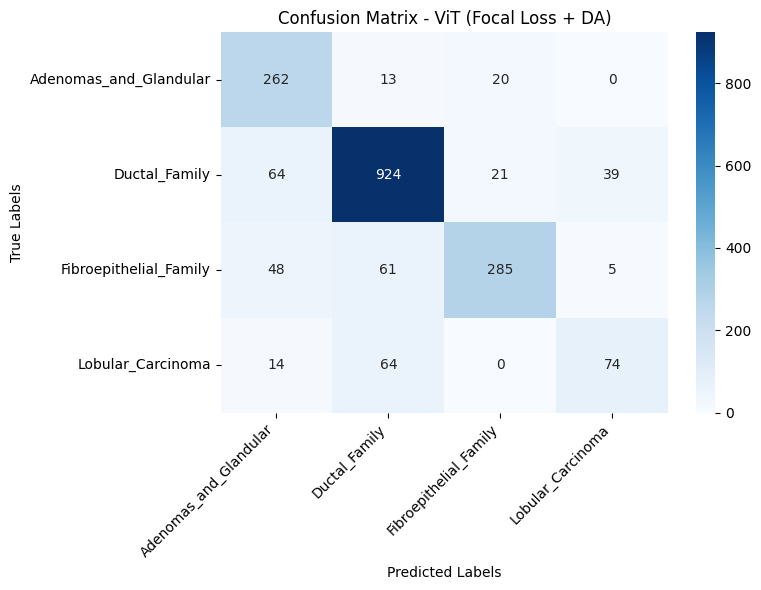

Model saved as 'vit_FocalLoss_4families.pth'


In [4]:
import os
import shutil
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. FOCAL LOSS IMPLEMENTATION
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for multi-class classification.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ==========================================
# 2. DATASET RE-STRUCTURING (4 FAMILIES)
# ==========================================
CLASS_MAPPING = {
    'ductal_carcinoma': 'Ductal_Family',
    'papillary_carcinoma': 'Ductal_Family',
    'mucinous_carcinoma': 'Ductal_Family',
    'fibroadenoma': 'Fibroepithelial_Family',
    'phyllodes_tumor': 'Fibroepithelial_Family',
    'adenosis': 'Adenomas_and_Glandular',
    'tubular_adenoma': 'Adenomas_and_Glandular',
    'lobular_carcinoma': 'Lobular_Carcinoma'
}

def get_patient_id(filename):
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_families_split(origin_path, final_path='/content/data_split_families', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        shutil.rmtree(final_p)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')

    for amp in zooms:
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]
        patients_dict = {c: {} for c in classes}

        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        for c in classes:
            all_patients = list(patients_dict[c].keys())
            if len(all_patients) == 1:
                train_p, test_p = all_patients, []
            else:
                train_p, test_p = train_test_split(all_patients, train_size=train_size, random_state=seed)

            super_class = CLASS_MAPPING.get(c, c)
            train_dest = final_p / 'train' / super_class
            test_dest = final_p / 'test' / super_class
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")

# Execute the split
source_path = '/content/dataset_original_local'
local_dest_path = '/content/data_split_families'
process_dataset_families_split(origin_path=source_path, final_path=local_dest_path)

# ==========================================
# 3. DATALOADERS & BALANCING
# ==========================================
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_da = datasets.ImageFolder(root='/content/data_split_families/train', transform=transform_train_da)
test_dataset = datasets.ImageFolder(root='/content/data_split_families/test', transform=transform_test)

class_counts = np.bincount(train_dataset_da.targets)
max_class_count = max(class_counts)
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset_da.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# Force int conversion to avoid PyTorch ValueError
balanced_num_samples = int(max_class_count * len(train_dataset_da.classes))
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

train_loader_da = DataLoader(train_dataset_da, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

# ==========================================
# 4. ViT MODEL INITIALIZATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vit_da = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in model_vit_da.parameters():
    param.requires_grad = True

num_ftrs = model_vit_da.heads.head.in_features
num_classes = len(train_dataset_da.classes)

model_vit_da.heads.head = nn.Linear(num_ftrs, num_classes)
model_vit_da = model_vit_da.to(device)

# Replace CrossEntropyLoss with FocalLoss
criterion = FocalLoss(gamma=2.0)
optimizer = optim.Adam(model_vit_da.parameters(), lr=0.0001)

# ==========================================
# 5. TRAINING LOOP
# ==========================================
NUM_EPOCHS = 15
print("Starting training for the 4-Families with Focal Loss (ViT)...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    model_vit_da.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_da:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model_vit_da(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    model_vit_da.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model_vit_da(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

# ==========================================
# 6. EVALUATION & CONFUSION MATRIX
# ==========================================
print("\nGenerating Detailed Performance Report per Family...")
class_names = [train_dataset_da.classes[i] for i in range(num_classes)]

report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Generate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT (Focal Loss + DA)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

save_path = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_FocalLoss_4families.pth"
torch.save(model_vit_da.state_dict(), save_path)
print(f"Model saved as 'vit_FocalLoss_4families.pth'")

Graphical representation of the data

/tmp/ipykernel_2018/3923215655.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', color='#1f77b4', linewidth=2)
/tmp/ipykernel_2018/3923215655.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--o" (-> color='r'). The keyword argument will take precedence.
  ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', color='#d62728', linewidth=2)
/tmp/ipykernel_2018/3923215655.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.
  ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', color='#1f77b4', linewidth=2)
/tmp/ipykernel_2018/3923215655.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--o" (-> col

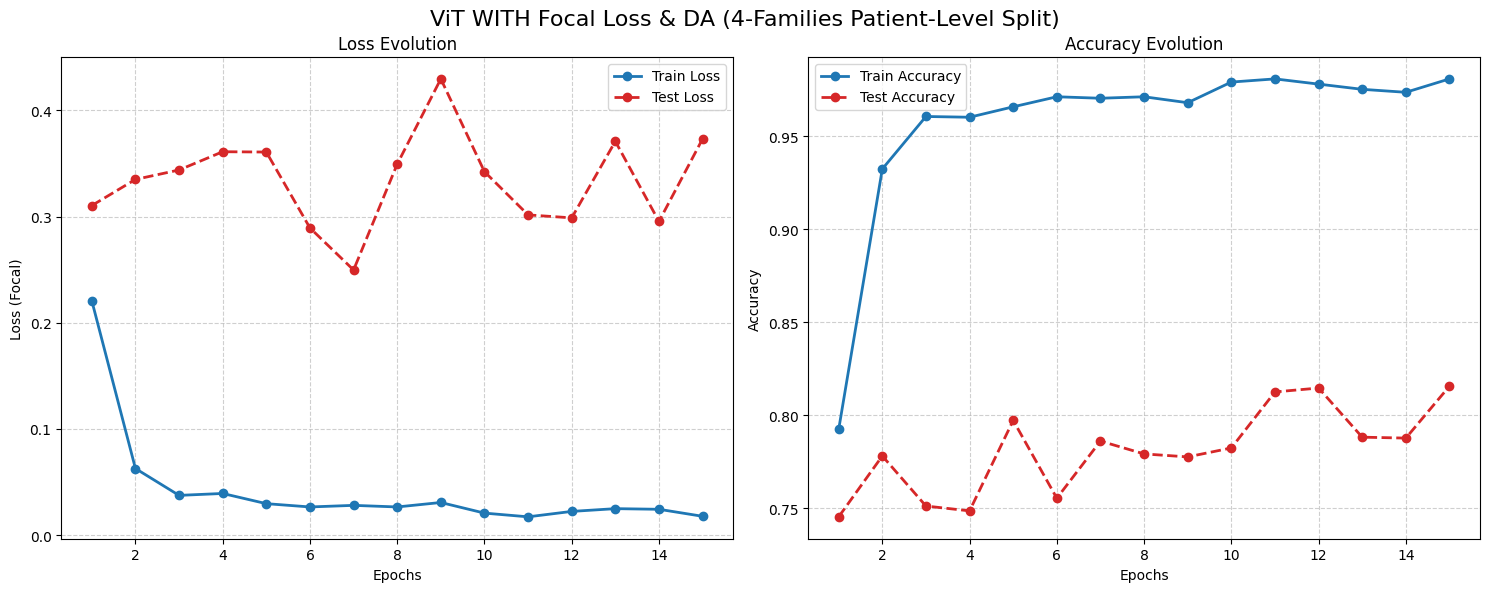

In [2]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (ViT WITH Focal Loss & DA - 4 Families)
epochs = list(range(1, 16))

train_loss = [0.2207, 0.0627, 0.0374, 0.0392, 0.0296, 0.0265, 0.0280, 0.0265, 0.0307, 0.0207, 0.0172, 0.0223, 0.0249, 0.0243, 0.0177]
test_loss = [0.3104, 0.3350, 0.3439, 0.3611, 0.3608, 0.2893, 0.2497, 0.3494, 0.4297, 0.3423, 0.3016, 0.2988, 0.3709, 0.2954, 0.3732]

train_acc = [0.7925, 0.9324, 0.9606, 0.9602, 0.9658, 0.9712, 0.9704, 0.9712, 0.9680, 0.9791, 0.9808, 0.9780, 0.9752, 0.9736, 0.9808]
test_acc = [0.7455, 0.7782, 0.7513, 0.7487, 0.7973, 0.7555, 0.7862, 0.7793, 0.7777, 0.7825, 0.8126, 0.8147, 0.7883, 0.7878, 0.8157]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT WITH Focal Loss & DA (4-Families Patient-Level Split)', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', color='#d62728', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Focal)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', color='#1f77b4', linewidth=2)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', color='#ff7f0e', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_4families_focal_loss_metrics.png', dpi=300) # Uncomment to save
plt.show()